In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# An Example from Water Quality Modeling

Water quality modeling is concerned with describing and predicting the **transport and transformation of substances in water systems**. These substances can be chlorine, nutrients, pollutants, sediments, dissolved oxygen, or other chemical and biological constituents that influence ecosystem health and water usability.

## Setup: Model Chlorine along a single Pipe

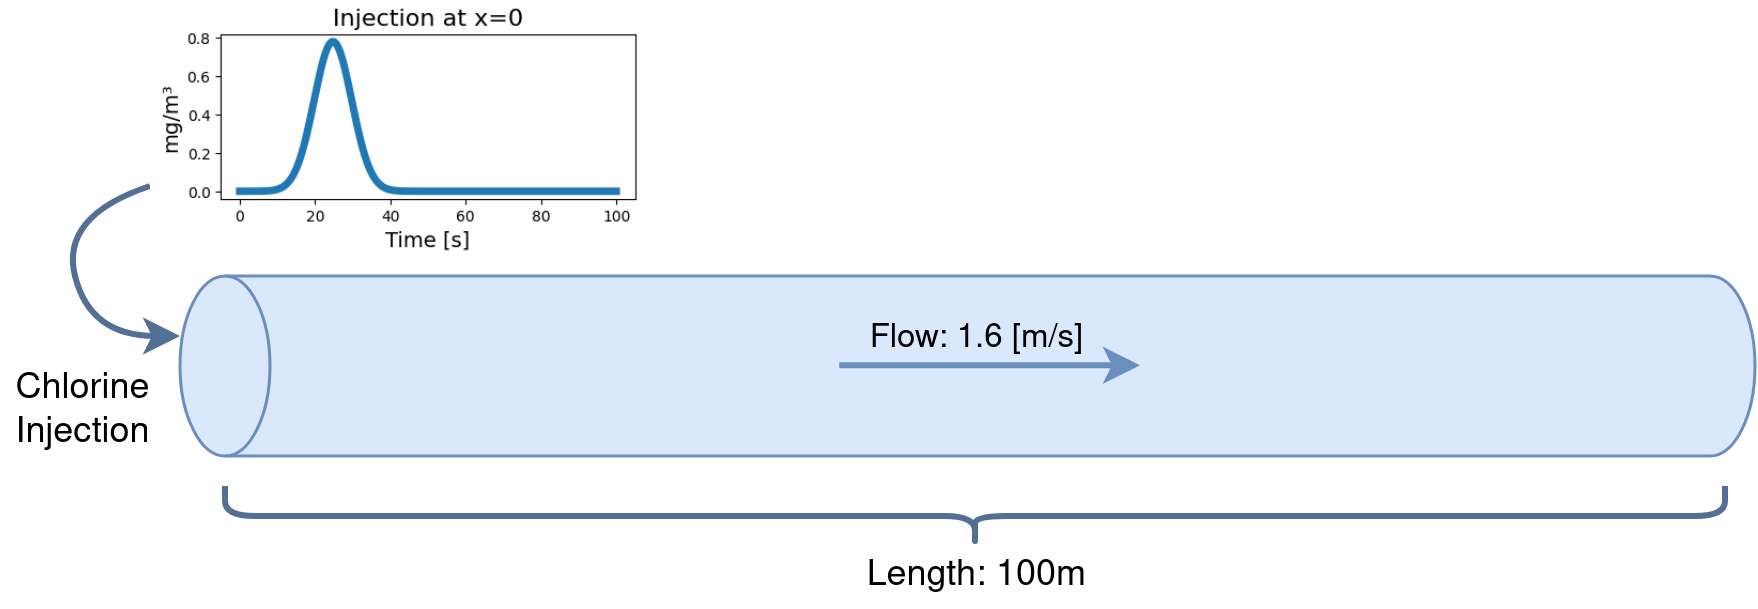

We approximate the domain of a pipe of length $L = 100[m]$ as a 1-dimensional space. Therefore, $x \in (0, L)$
We model this on a 1-dimensional domain of length $L = 100[m]$, over a time period of $T = 100[s]$.

## PINN Example: Advection-Diffusion-Reaction

In the water quality domain, the Advection-Diffusion-Reaction PDE (ADR) is very important. It models three dynamics at the same time:
  1. **A**dvection: The transport of a substance in the presence of a flow field.
  2. **D**iffusion/Dispersion: Spread of the substance due to additional effects (turbulence, eddy currents, molecular motion)
  3. **R**eaction: Chemical reactions and decay of substances

The PDE is as follows:

$$
\frac{\partial u}{\partial t} = -v \frac{\partial u}{\partial x} + D \frac{\partial^2 u}{\partial x^2} - ku
$$

We first define the domain parameters:

In [ ]:
diffusion = 0.2
k = 0.01
flow_speed = 1.6
L = 100 # [100m]
T = 100 # [sec]

 ### Initial- and Boundary Conditions

 The initial condition is zero (no chlorine in the pipe), and the injection bounadry condition is a gaussian pulse injection of chlorine (Dirichlet boundary). The choice of the Gaussian pulse is deliberate, since this allows an analytical solution to check the results.

In [ ]:
def bc_left(t, peak_val=1., peak_time=0.25, sigma=0.005):
    '''
    Boundary Condition (Dirichlet) at the left side.
    '''
    return peak_val * torch.exp(-(t - peak_time)**2/sigma)

# Right side boundary is an outflow condition (free bounadry)
# Initial Condition is Zero, we don't need to explicitly generate this.
plt.figure(figsize=(10, 3))
plt.plot(bc_left(torch.linspace(0, 1, 200)))
plt.title('Chlorine Injection (Left-Boundary)')
plt.xlabel('Time [s]')
_ = plt.ylabel(r'Chlorine $mg/m^3$')

## Setup the Model

Note that we do not need to generate training data, knowing the setup and the PDE equation is enough!
Therefore, we can already build the model.

 * **Architecture:** MLP
 * **Depth:** 3 Layers + 1 Input and 1 Output Layer
 * **Width:** 64 Neurons in the hidden layers
 * **Input dimensionality:** 2 (Space coordinate $x \in [0, L]$, Time coordinate $t \in [0, T]$)
 * **Output dimensionality:** 1 (Chlorine concentration at location $x$ and time $t$).

  * **Note:** Normalization of space-time coordinate in the forward call. PINNs are very sensitive to input scaling.

In [ ]:
class PINN(torch.nn.Module):

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.net = nn.Sequential(
          nn.Linear(2, 64),  nn.Tanh(),
          nn.Linear(64, 64), nn.Tanh(),
          nn.Linear(64, 64), nn.Tanh(),
          nn.Linear(64, 64), nn.Tanh(),
          nn.Linear(64, 1),
      )

    def forward(self, x, t, L, T):
        x = x / L
        t = t / T
        xt = torch.cat((x, t), dim=-1)
        return self.net(xt)

### Set the Hyperparameters and Initialize the Model

It is relatively standard practice to use a learning-rate scheduler, and the Adam optimizer. I tuned the learning-rate a little bit by hand and $0.01$ works.

> Generally it is a bit finnicky to train a PINN when it comes to hyperparameters. You can check [An Expert's Guide to Training Physics-informed Neural Networks (Wang et al. 2023)](https://arxiv.org/abs/2308.08468) for general best practices.

In [ ]:
# This is quite aggressive but for our example it works
lr = 0.01
# Scale Learning-Rate every 1000 epochs by 0.1
decay = np.log(0.1) / 1000 + 1
# Training epochs, we can get away with only 2000, typically this is higher
epochs = 2000

s_pde = max(L, T)

pinn = PINN().to(device)
op = torch.optim.Adam(pinn.parameters(), lr)
schedule = torch.optim.lr_scheduler.ExponentialLR(op, gamma=decay)

## Physics-Objective: Loss Terms

As discussed earlier, we need three loss terms for
 * **PDE:** MSE of the PDE residual
 * **Boundary-Conditions:** Standard MSE prediction vs. ground truth
 * **Initial-Conditions:** Standard MSE prediction vs. ground truth

$$\begin{align*}
\mathcal{L}_{PDE}(x, t) &= \left(
u_t(x, t) + v u_x(x, t) - D u_{xx}(x, t) + ku(x, t)
\right)^2 \\
\mathcal{L}_{BC}(x, t) &= \left(0 - u(0, t)\right)^2 \\
\mathcal{L}_{IC}(x, t) &= \left(0 - u(x, 0)\right)^2
\end{align*}$$

This yields the final loss:

$$
\mathcal{L}_{total}(x, t) = \lambda_{pde} \mathcal{L}_{PDE}(x, t) + \lambda_{bc} \mathcal{L}_{BC}(x, t) + \lambda_{ic} \mathcal{L}_{IC}(x, t)
$$

> And yes, the balancing of the different loss terms is a nightmare, but Wang et al. has an answer for that as well.

In [ ]:
def pde_loss(pinn):
    '''
    Here we define the PDE loss, for that we have to compute the different derivatives,
    but first we need random points at which we compute the PDE loss.
    '''
    # Sample some points
    x = torch.rand(5000, 1, device=device) * L
    t = torch.rand(5000, 1, device=device) * T
    # We derive w.r.t. these points, hence they require a gradient
    x = x.requires_grad_(True)
    t = t.requires_grad_(True)

    # Make a prediction
    u = pinn(x, t, L, T)

    # Compute derivatives: This is the PINN specific part:
    du_dx,   = torch.autograd.grad(u,     x, torch.ones_like(u),     create_graph=True)
    d2u_dx2, = torch.autograd.grad(du_dx, x, torch.ones_like(du_dx), create_graph=True)
    du_dt,   = torch.autograd.grad(u,     t, torch.ones_like(u),     create_graph=True)

    # This is L_{PDE}
    residual_loss = (du_dt + flow_speed * du_dx - diffusion * d2u_dx2 + k * u).square()

    # Return the average loss over the samples
    return residual_loss.mean()

def bc_losses(pinn):
    '''
    The boundary condition loss is also computed over samples. Note that
    we do it only for the left boundary, i.e. for x = 0.
    '''
    # Sample some points
    bc_ts = torch.rand(1000, 1, device=device) * T
    bcl_xs = torch.zeros(1000, 1, device=device)

    # Make a prediction
    u = pinn(bcl_xs, bc_ts, L, T)

    # Compare to ground-truth injection (MSE-loss)
    bc_loss = (bc_left(bc_ts/T) - u).square()

    return bc_loss.mean()

def ic_losses(pinn):
    '''
    The initial condition loss is also computed over samples. At time t = 0.
    '''
    ic_xs = torch.rand(1000, 1, device=device) * L
    ic_ts = torch.zeros_like(ic_xs)

    u = pinn(ic_xs, ic_ts, L, T)

    # We have an initial condition of zero, so MSE reduces to:
    ic_loss = u.square()

    return ic_loss.mean()

## Run the Optimization

In [ ]:
# Initialize some lists to store the losses during training
data_losses, residual_losses = [], []
process = tqdm(range(epochs))

# This is the standard Training Loop:
for e in process:
    op.zero_grad()

    residual_loss = pde_loss(pinn)
    bc_loss = bc_losses(pinn)
    ic_loss = ic_losses(pinn)

    # Here we compute the total loss ...
    loss = 100 * ic_loss + 10 * bc_loss + s_pde * residual_loss
    # ... perform backpropagation
    loss.backward()
    # ... apply the gradients to the model parameters
    loss = op.step()
    schedule.step()
    if e % 100 == 0:
        data_losses.append((ic_loss + bc_loss).detach().item())
        residual_losses.append(residual_loss.detach().item())
    process.set_description('Loss: {:.5f}'.format((ic_loss + bc_loss + s_pde * residual_loss).detach().item()))

In [ ]:
plt.subplots(figsize=(10, 3))
plt.semilogy(data_losses, label=r'Data loss ($\mathcal{L}_{BC} + \mathcal{L}_{IC}$)')
plt.semilogy(residual_losses, label=r'PDE loss ($\mathcal{L}_{PDE})$')
plt.title('Losses'); plt.legend()
plt.xlabel('Epoch')

### First Results

This looks a lot like something flows from the left boundary to the right boundary. However, we have to do better - and we can!

In [ ]:
xs = np.linspace(0, L, 100)
ts = np.arange(0, T, 1, dtype=float)
test = np.stack(np.meshgrid(xs, ts)).reshape(2, -1)

prediction = pinn(*torch.as_tensor(test.copy()).float().unsqueeze(-1).to(device), L, T)
prediction = prediction.reshape(100, 100, 1).detach().cpu().squeeze(-1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))
ax1.imshow(prediction, extent=(0, L, 0, T), aspect='auto', origin='lower')

for t, pred_t in zip(ts[::10], prediction[::10]):
    ax2.plot(xs, pred_t, color=plt.cm.Blues(t/T), label=f't = {t:.0f}s')

plt.legend(ncol=3); ax1.set_xlabel(r'Pipe Space $x$'); ax1.set_ylabel(r'Time $t$')
ax2.set_ylabel(r'Chlorine Concentration $mg/m^3$'); _ = ax2.set_xlabel(r'Pipe Space $x$')

## One last (but very useful) Trick: L-BFGS

Since it's all about precision in physical modelling, we should finetune our model with a different optimizer: L-BFGS
This can be used to queeze the model for every bit of precision is get provide.
Its a Newton method and much better at finding narrow minima than the Adam optimizer is.

In [ ]:
op = torch.optim.LBFGS(pinn.parameters(), max_iter=100, history_size=50, line_search_fn='strong_wolfe')

ic_loss = bc_loss = residual_loss = None

def closure():
    # This is one way to store the losses (you can ignore it)
    global ic_loss, bc_loss, residual_loss
    # Second-order methods hate noise, so we need to fix the random x and t samples
    # We can do this with a random seed
    torch.manual_seed(0)
    # Rest is the same training code we used with Adam before (copy & pasted)
    op.zero_grad()
    residual_loss = pde_loss(pinn)
    bc_loss = bc_losses(pinn)
    ic_loss = ic_losses(pinn)
    loss = 100 * ic_loss + 10 * bc_loss + s_pde * residual_loss
    loss.backward()
    return loss

process = tqdm(range(100))

for e in process:
    op.step(closure)
    data_losses.append((ic_loss + bc_loss).detach().item())
    residual_losses.append(residual_loss.detach().item())
    process.set_description('{:.5f}'.format(1000 * (ic_loss + bc_loss + s_pde * residual_loss).detach().item()))

In [ ]:
plt.subplots(figsize=(10, 3))
plt.semilogy(data_losses, label=r'Data loss ($\mathcal{L}_{BC} + \mathcal{L}_{IC}$)')
plt.semilogy(residual_losses, label=r'PDE loss ($\mathcal{L}_{PDE})$')
plt.title('Losses'); plt.legend()
plt.xlabel('Epoch')

In [ ]:
xs = np.linspace(0, L, 100)
ts = np.arange(0, T, 1, dtype=float)
test = np.stack(np.meshgrid(xs, ts)).reshape(2, -1)

prediction = pinn(*torch.as_tensor(test.copy()).float().unsqueeze(-1).to(device), L, T)
prediction = prediction.reshape(100, 100, 1).detach().cpu().squeeze(-1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))
ax1.imshow(prediction, extent=(0, L, 0, T), aspect='auto', origin='lower')

for t, pred_t in zip(ts[::10], prediction[::10]):
    ax2.plot(xs, pred_t, color=plt.cm.Blues(t/T), label=f't = {t:.0f}s')

plt.legend(ncol=3); ax1.set_xlabel(r'Pipe Space $x$'); ax1.set_ylabel(r'Time $t$')
ax2.set_ylabel(r'Chlorine Concentration $mg/m^3$'); _ = ax2.set_xlabel(r'Pipe Space $x$')

## Let's animate the solution

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(10, 3))

line, = ax.plot(xs, prediction[0].detach().cpu())

def update(f):
  line.set_data(xs, prediction[f].detach().cpu())

ax.set_ylim(-0.05, 1 + 0.05)

anim = FuncAnimation(fig, update, range(100), interval=60)

HTML(anim.to_html5_video())
plt.close()